#**Cyber attack Trends**

**Project Title**

Cyberattack Trends by Sector using Machine Learning

Leader in Consulting

https://gncipl.com/

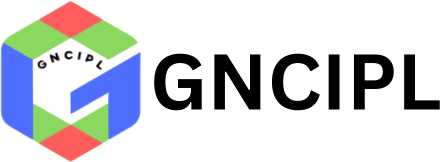


**GitHub Repository**

https://github.com/simranbhadouria/Cyber-attack-Trends-project-7/new/main?filename=README.md

**Dataset**

https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks

**Objective**

Analyze publicly reported cyber incidents across industries and answer:

Which sectors are attacked the most?
How has attack frequency changed over time?
What are the top attack vectors?
Can we predict future cyberattack trends?

In [36]:
#Install Libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [37]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [38]:
#Load DataSet
df = pd.read_csv("/content/cybersecurity_attacks.csv")

In [39]:
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [40]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [41]:
#Data Cleaning
print(df.isnull().sum())

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64


In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df.fillna("Unknown", inplace=True)

**Machine Learning Model**

In [80]:
# Create LabelEncoder objects
le_network = LabelEncoder()
le_geo = LabelEncoder()
le_traffic = LabelEncoder()
le_attack = LabelEncoder()

# Encode Network Segment
df["Network_Segment_Encoded"] = le_network.fit_transform(df["Network Segment"])
df["Geo_location_Encoded"] = le_geo.fit_transform(df["Geo-location Data"])
df["Traffic_Type_Encoded"] = le_traffic.fit_transform(df["Traffic Type"])
df["Attack_Type_Encoded"] = le_attack.fit_transform(df["Attack Type"])

# Display results
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source,Network_Segment_Encoded,Geo_location_Encoded,Traffic_Type_Encoded,Attack_Type_Encoded,Year
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,"Jamshedpur, Sikkim",150.9.97.135,Log Data,Unknown,Server,0,3723,2,2,2023
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,"Bilaspur, Nagaland",Unknown,Log Data,Unknown,Firewall,1,1677,2,2,2020
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall,2,1707,2,0,2022
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,"Jaunpur, Rajasthan",Unknown,Unknown,Alert Data,Firewall,1,3750,2,2,2023
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,"Anantapur, Tripura",149.6.110.119,Unknown,Alert Data,Firewall,2,577,0,0,2023


In [85]:
#Predict Attack Type
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year'] = df['Timestamp'].dt.year
year_attacks = df.groupby('Year').size()

print(year_attacks)
X = df[["Year", "Network_Segment_Encoded", "Geo_location_Encoded", "Traffic_Type_Encoded", "Anomaly Scores"]]
y = df["Attack_Type_Encoded"]


Year
2020    10573
2021    10538
2022    10750
2023     8139
dtype: int64


In [79]:
#Split Dataset and Train AI/ML Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [48]:
#Prediction
predictions = rf.predict(X_test)
print(predictions[:10])

[1 2 1 0 1 0 0 0 2 0]


In [49]:
#Accuracy
accuracy = accuracy_score(y_test,predictions)
print("Accuracy =", accuracy)

Accuracy = 0.323


In [50]:
#Classification Report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.32      0.33      0.32      2636
           1       0.33      0.31      0.32      2721
           2       0.32      0.33      0.32      2643

    accuracy                           0.32      8000
   macro avg       0.32      0.32      0.32      8000
weighted avg       0.32      0.32      0.32      8000



In [51]:
#Feature Importance
importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})

print(importance.sort_values(by="Importance",ascending=False))

                   Feature  Importance
2     Geo_location_Encoded    0.470716
4           Anomaly Scores    0.470175
0                     Year    0.023744
3     Traffic_Type_Encoded    0.018395
1  Network_Segment_Encoded    0.016969


<Figure size 500x500 with 0 Axes>

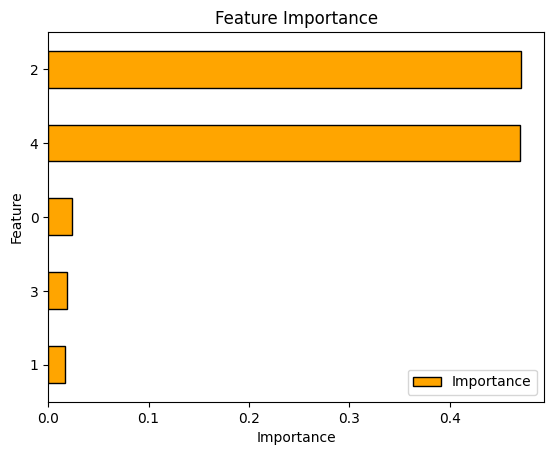

In [89]:
plt.figure(figsize = (5,5), facecolor ='lightblue')
importance.sort_values(by="Importance",ascending=True).plot(kind="barh",color = 'orange', edgecolor = 'black')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [92]:
#Predict Future Attack Type
future_data = pd.DataFrame({"Year":[2027],"Network_Segment_Encoded":[0],"Geo_location_Encoded":[100],"Traffic_Type_Encoded":[1],"Anomaly Scores":[75.5]})

prediction = rf.predict(future_data)
print(prediction)

[1]


In [93]:
#Convert prediction back to text:
attack_name = le_attack.inverse_transform(prediction)

print("Predicted Attack:", attack_name[0])

Predicted Attack: Intrusion


In [94]:
attack_vector = df['Attack Type'].value_counts()

print(attack_vector)

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


**Exploratory Data Analysis**

In [52]:
#Exploratory Data Analysis
attack_type_counts = df['Attack Type'].value_counts()

print(attack_type_counts)

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


In [53]:
print(df.shape)
print(df.columns)
print(df.describe())

(40000, 30)
Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source',
       'Network_Segment_Encoded', 'Geo_location_Encoded',
       'Traffic_Type_Encoded', 'Attack_Type_Encoded', 'Year'],
      dtype='object')
                           Timestamp   Source Port  Destination Port  \
count                          40000  40000.000000      40000.000000   
mean   2021-11-22 06:17:52.200800256  32970.356450      33150.868650   
min              2020-01-01 00:43:27   1027.000000       1024.000000   
25%       2020-12-12 19:56:28.500000  16850.750000      1

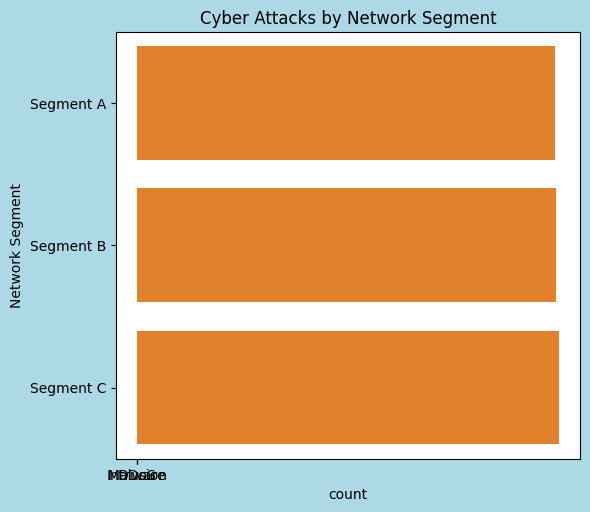

In [54]:
#Visualization
plt.figure(figsize=(6,5), facecolor = 'lightblue')
plt.bar(attack_type_counts.index, attack_type_counts.values)
sns.countplot(data=df, y='Network Segment')
plt.tight_layout()
plt.title("Cyber Attacks by Network Segment")
plt.show()

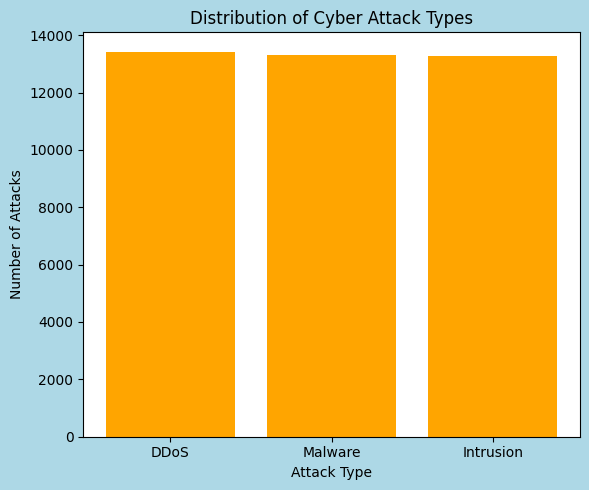

In [55]:
plt.figure(figsize=(6,5), facecolor='lightblue')
plt.bar(attack_type_counts.index, attack_type_counts.values, color='orange')
plt.title("Distribution of Cyber Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Attacks")
plt.tight_layout()
plt.show()

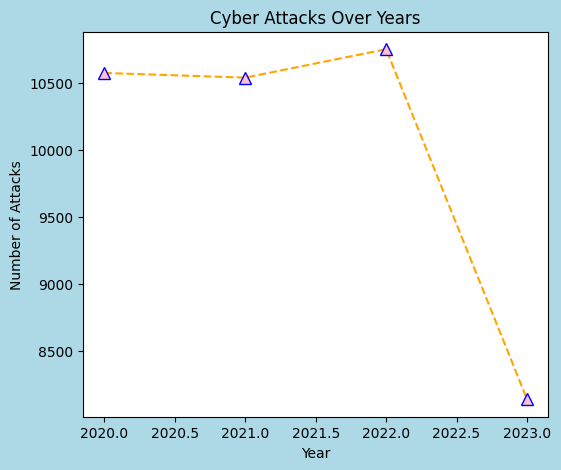

In [60]:
plt.figure(figsize=(6,5),facecolor = 'lightblue')
year_attacks.plot(kind='line', marker='^', linestyle = '--', color = 'orange', markerfacecolor = 'pink', markeredgecolor = 'blue', markersize = 8)

plt.title("Cyber Attacks Over Years")
plt.ylabel("Number of Attacks")
plt.show()

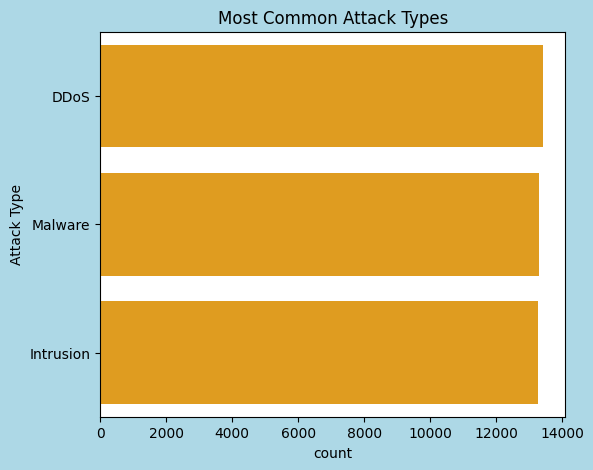

In [71]:
plt.figure(figsize=(6,5),facecolor = 'lightblue')
sns.countplot(data=df, y='Attack Type', order=df['Attack Type'].value_counts().index, color= "orange")
plt.title("Most Common Attack Types")
plt.show()

In [63]:
pd.crosstab(df['Network Segment'],df['Attack Type'])

Attack Type,DDoS,Intrusion,Malware
Network Segment,,,
Segment A,4445,4349,4479
Segment B,4466,4497,4356
Segment C,4517,4419,4472


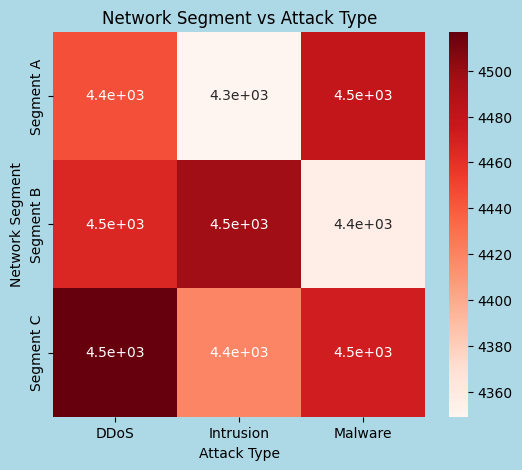

In [74]:
cross = pd.crosstab(df['Network Segment'],df['Attack Type'])
plt.figure(figsize=(6,5), facecolor = 'lightblue')
sns.heatmap(cross, annot=True,cmap="Reds")

plt.title("Network Segment vs Attack Type")
plt.show()

In [65]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.32      0.33      0.32      2636
           1       0.33      0.31      0.32      2721
           2       0.32      0.33      0.32      2643

    accuracy                           0.32      8000
   macro avg       0.32      0.32      0.32      8000
weighted avg       0.32      0.32      0.32      8000



In [66]:
yearly = df.groupby('Year').size()

print(yearly)

Year
2020    10573
2021    10538
2022    10750
2023     8139
dtype: int64


In [67]:
from sklearn.linear_model import LinearRegression

X = yearly.index.values.reshape(-1,1)
y = yearly.values
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [68]:
future_years = np.array([2026,2027,2028,2029,2030]).reshape(-1,1)
future_predictions = model.predict(future_years)
print(future_predictions)

[6809.5 6100.5 5391.5 4682.5 3973.5]


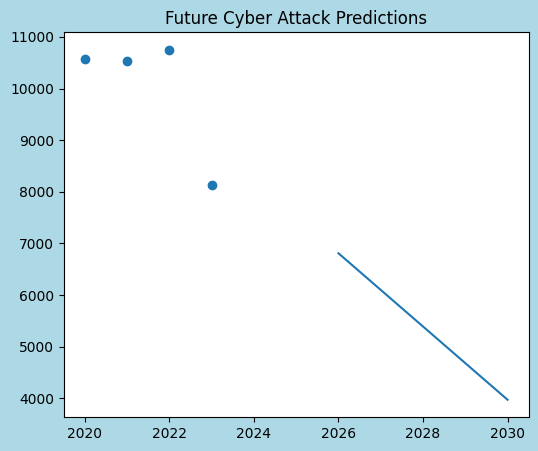

In [75]:
plt.figure(figsize=(6,5), facecolor = 'lightblue')
plt.scatter(yearly.index, yearly.values)
plt.plot(future_years,future_predictions)

plt.title("Future Cyber Attack Predictions")
plt.show()

In [70]:
df.to_csv("cybersecurity_attacks_cleaned.csv", index=False)

**Project Conclusion**

Cyberattack Trends by Sector Using Machine Learning

This project analyzed cybersecurity attack data to understand attack patterns, identify high-risk sectors, and predict cyberattack types using Machine Learning. The dataset was cleaned, transformed, and explored using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.

Exploratory Data Analysis revealed significant variations in cyberattack frequency across different network segments, geographic locations, and traffic types. Visualization techniques helped identify the most common attack categories and their distribution over time.

A Random Forest Machine Learning model was developed to predict attack types based on features such as network segment, geographical location, traffic type, anomaly score, and attack severity level. Feature importance analysis highlighted the factors that contribute most to cyber threats.

The project also included trend analysis and future attack forecasting, providing insights into potential cybersecurity risks. The cleaned dataset can be integrated with Power BI dashboards to support data-driven security monitoring and decision-making.

Key Achievements

Cleaned and preprocessed cybersecurity attack data.
Performed Exploratory Data Analysis (EDA).
Identified major attack trends and threat patterns.
Built a Random Forest classification model.
Predicted future cyberattack behavior.
Created data visualizations for business insights.
Generated a dashboard-ready dataset for Power BI.